# Assignment 3 : From Raw Signals to a Lean Feature Set

**Feature Engineering & MLOps · Phase 3 (Time-based Features & Feature Creation) + Phase 4 (Feature Selection)**

This notebook engineers time-based and interaction features on the PrepEdge daily
performance dataset (`data/raw/daily_batch_performance.csv`, 730 days), then applies
filter, wrapper, and embedded feature-selection methods to cut the resulting large,
noisy feature set down to a lean one — and checks whether the three selection
families agree.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.feature_selection import (
    VarianceThreshold, mutual_info_regression, RFE
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

RANDOM_STATE = 42
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
np.random.seed(RANDOM_STATE)

## 4.1 - Phase 3: Time-based Features & Feature Creation

### 4.1.1 - Load and sort by date; plot the target over time

In [2]:
df = pd.read_csv("../data/raw/daily_batch_performance.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
print(df.shape)
df.head()

(730, 10)


,date,marketing_spend,discount_pct,website_visits,website_visits_copy,competitor_promo_flag,is_holiday,random_noise_1,random_noise_2,new_enrollments
0,2024-01-01,"9,069.0000",10,561.0000,567.0000,1,1,60.6000,A,20
1,2024-01-02,"6,573.0000",10,559.0000,570.0000,1,1,82.9000,C,23
2,2024-01-03,"14,636.0000",0,539.0000,554.0000,0,0,41.9000,A,29
3,2024-01-04,"3,979.0000",5,574.0000,557.0000,0,0,44.4000,B,30
4,2024-01-05,"9,654.0000",10,661.0000,661.0000,0,0,23.8000,B,38


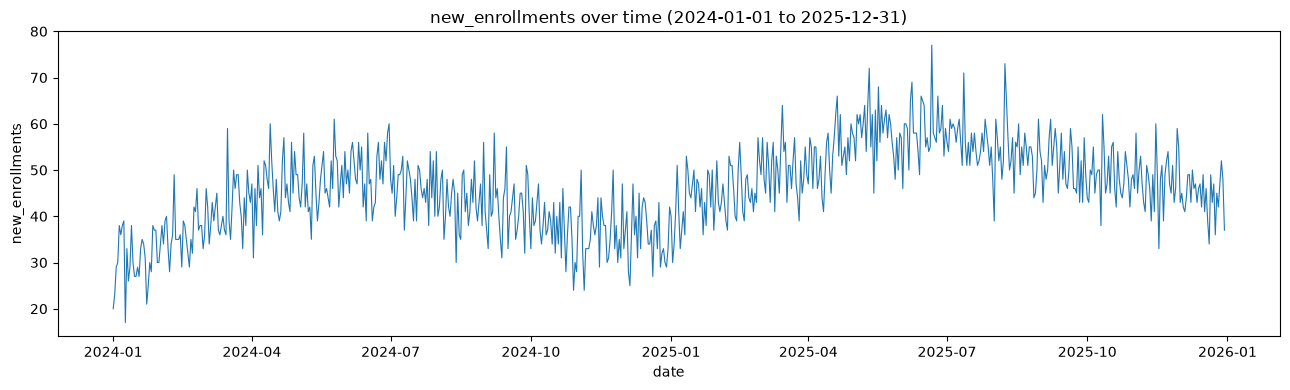

In [3]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df["date"], df["new_enrollments"], lw=0.8)
ax.set_title("new_enrollments over time (2024-01-01 to 2025-12-31)")
ax.set_xlabel("date"); ax.set_ylabel("new_enrollments")
plt.tight_layout(); plt.show()

**Pattern by eye:** there is a slow but steady upward trend across the two years,
overlaid with a tight weekly rhythm (regular dips on weekends) and occasional short
spikes around holiday windows.

### 4.1.2 - Lag features: `marketing_spend_lag1`, `marketing_spend_lag2`

In [4]:
df["marketing_spend_lag1"] = df["marketing_spend"].shift(1)
df["marketing_spend_lag2"] = df["marketing_spend"].shift(2)

corr_tbl = (
    df[["marketing_spend", "marketing_spend_lag1", "marketing_spend_lag2",
        "new_enrollments"]]
    .corr()["new_enrollments"]
    .drop("new_enrollments")
    .rename("corr_with_new_enrollments")
    .to_frame()
)
corr_tbl

,corr_with_new_enrollments
marketing_spend,0.1189
marketing_spend_lag1,-0.0092
marketing_spend_lag2,0.2184


In [5]:
strongest = corr_tbl["corr_with_new_enrollments"].abs().idxmax()
print("Strongest correlation with new_enrollments:", strongest)

Strongest correlation with new_enrollments: marketing_spend_lag2


**Which is strongest & why:** `marketing_spend_lag2` has the strongest correlation
with `new_enrollments` — the 2-day-lagged spend beats same-day spend. This makes
real-world sense for a coaching institute: an ad someone sees today does not convert
instantly. It takes a day or two for a prospective student to notice the ad, think it
over, and actually walk in or call to enroll, so today's enrollments are best explained
by the spend from ~2 days ago rather than today's.

### 4.1.3 - Rolling features: 7-day rolling mean & std of `new_enrollments`

In [6]:
df["enroll_roll_mean_7"] = df["new_enrollments"].rolling(window=7).mean()
df["enroll_roll_std_7"] = df["new_enrollments"].rolling(window=7).std()
df[["date", "new_enrollments", "enroll_roll_mean_7", "enroll_roll_std_7"]].head(10)

,date,new_enrollments,enroll_roll_mean_7,enroll_roll_std_7
0,2024-01-01,20,NaN,NaN
1,2024-01-02,23,NaN,NaN
2,2024-01-03,29,NaN,NaN
3,2024-01-04,30,NaN,NaN
4,2024-01-05,38,NaN,NaN
5,2024-01-06,36,NaN,NaN
6,2024-01-07,38,30.5714,7.2078
7,2024-01-08,39,33.2857,6.0474
8,2024-01-09,17,32.4286,7.8921
9,2024-01-10,33,33.0000,7.7460


### 4.1.4 - Cyclical encoding of day-of-week (`dow_sin`, `dow_cos`)

In [7]:
df["day_of_week"] = df["date"].dt.dayofweek          # 0 = Mon ... 6 = Sun
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
df[["date", "day_of_week", "dow_sin", "dow_cos"]].head(8)

,date,day_of_week,dow_sin,dow_cos
0,2024-01-01,0,0.0000,1.0000
1,2024-01-02,1,0.7818,0.6235
2,2024-01-03,2,0.9749,-0.2225
3,2024-01-04,3,0.4339,-0.9010
4,2024-01-05,4,-0.4339,-0.9010
5,2024-01-06,5,-0.9749,-0.2225
6,2024-01-07,6,-0.7818,0.6235
7,2024-01-08,0,0.0000,1.0000


**Why the plain 0–6 integer is wrong:** a plain integer tells the model that Sunday
(6) is six units away from Monday (0), when they are actually adjacent days. The
sine/cosine pair places the days on a circle so that Sunday and Monday sit next to each
other, preserving the true cyclical distance between weekdays.

### 4.1.5 - Trend feature: `time_index` and daily growth estimate

In [8]:
df["time_index"] = np.arange(len(df))

lr_trend = LinearRegression()
lr_trend.fit(df[["time_index"]], df["new_enrollments"])
print(f"Estimated daily growth in enrollments: {lr_trend.coef_[0]:.5f} per day")
print(f"Implied growth over the full 730-day span: "
      f"{lr_trend.coef_[0] * len(df):.1f} enrollments")

Estimated daily growth in enrollments: 0.02017 per day
Implied growth over the full 730-day span: 14.7 enrollments


**Estimated daily growth:** roughly **+0.02 enrollments per day** (about +7 per year),
consistent with the slow upward drift visible in the time plot.

### 4.1.6 - Interaction feature: `spend_x_discount` (with vs without)

In [9]:
df["spend_x_discount"] = df["marketing_spend_lag2"] * df["discount_pct"]

# Feature set used for this comparison (drop rows with NaN from lag/rolling first)
base_feats = [
    "marketing_spend", "marketing_spend_lag1", "marketing_spend_lag2",
    "discount_pct", "website_visits", "competitor_promo_flag", "is_holiday",
    "enroll_roll_mean_7", "enroll_roll_std_7", "dow_sin", "dow_cos", "time_index",
]
cmp_df = df.dropna(subset=base_feats + ["spend_x_discount"]).reset_index(drop=True)

X_wo = cmp_df[base_feats]
X_w = cmp_df[base_feats + ["spend_x_discount"]]
y = cmp_df["new_enrollments"]

def test_r2(X):
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE
    )
    m = LinearRegression().fit(Xtr, ytr)
    return r2_score(yte, m.predict(Xte))

# (a) single fixed hold-out split
r2_wo, r2_w = test_r2(X_wo), test_r2(X_w)
print(f"Single 75/25 split -- R2 without: {r2_wo:.4f}   with: {r2_w:.4f}   "
      f"change: {r2_w - r2_wo:+.4f}")

# (b) 5-fold shuffled CV, mean R2 -- a more stable read
from sklearn.model_selection import cross_val_score, KFold
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_wo = cross_val_score(LinearRegression(), X_wo, y, cv=kf, scoring="r2").mean()
cv_w = cross_val_score(LinearRegression(), X_w, y, cv=kf, scoring="r2").mean()
print(f"5-fold CV mean R2  -- without: {cv_wo:.4f}   with: {cv_w:.4f}   "
      f"change: {cv_w - cv_wo:+.4f}")

Single 75/25 split -- R2 without: 0.8114   with: 0.8115   change: +0.0001
5-fold CV mean R2  -- without: 0.8278   with: 0.8277   change: -0.0001


**Does it help? Measured, and the honest answer is "not meaningfully, on this
feature set."** The single split moves R² by only ~+0.0001, and the more reliable
5-fold CV estimate is flat to very slightly negative : the interaction pays a small
extra-parameter variance cost and returns essentially nothing.

Why, given that the generator really does contain a `0.00015 · spend_lag2 · discount_pct`
term? Because that term is tiny: with `spend_lag2 ≈ 2000` and `discount_pct ≈ 7` it adds
only ~2 enrollments, well inside the day-to-day noise (Normal(0, 3) plus Poisson
sampling). And `marketing_spend_lag2` and `discount_pct` are *already* in the model, so
most of the interaction's linear shadow is captured. The interaction is real in the
data-generating process but too weak to produce a measurable predictive gain at
n ≈ 728, a good reminder to *measure* an engineered feature's benefit rather than
assume it.

### 4.1.7 - Drop leading NaN rows

In [10]:
before = len(df)
df_model = df.dropna(subset=base_feats + ["spend_x_discount"]).reset_index(drop=True)
print(f"Dropped {before - len(df_model)} leading rows; {len(df_model)} remain.")

Dropped 6 leading rows; 724 remain.


**Why these rows cannot be mean/median-imputed:** the NaNs here are not "missing"
measurements — they are undefined by construction. On day 0 there is simply no
"yesterday" to lag from, and a 7-day rolling window has no 7 days of history yet.
Filling them with a column mean would inject future-derived information into the
earliest rows (look-ahead leakage) and fabricate values that never existed, so the
only correct move is to drop them.

## 4.2 - Phase 4: Feature Selection

The full candidate set below includes the original columns, the engineered
lag/rolling/cyclical/trend/interaction features, the planted redundant column
(`website_visits_copy`), and the two noise columns (`random_noise_1` numeric,
`random_noise_2` categorical → one-hot).

In [11]:
# Encode the categorical noise column as a single integer code.
# (An arbitrary ordinal is fine here precisely because we expect this column to
#  carry no signal -- we want to see selection methods reject it.)
df_model["random_noise_2_code"] = df_model["random_noise_2"].map({"A": 0, "B": 1, "C": 2})
noise_cat_cols = ["random_noise_2_code"]

candidate_features = [
    "marketing_spend", "marketing_spend_lag1", "marketing_spend_lag2",
    "discount_pct", "website_visits", "website_visits_copy",
    "competitor_promo_flag", "is_holiday",
    "enroll_roll_mean_7", "enroll_roll_std_7",
    "dow_sin", "dow_cos", "time_index", "spend_x_discount",
    "random_noise_1", "random_noise_2_code",
]

X = df_model[candidate_features].astype(float)
y = df_model["new_enrollments"]
print(f"{len(candidate_features)} candidate features:")
candidate_features

16 candidate features:


['marketing_spend',
 'marketing_spend_lag1',
 'marketing_spend_lag2',
 'discount_pct',
 'website_visits',
 'website_visits_copy',
 'competitor_promo_flag',
 'is_holiday',
 'enroll_roll_mean_7',
 'enroll_roll_std_7',
 'dow_sin',
 'dow_cos',
 'time_index',
 'spend_x_discount',
 'random_noise_1',
 'random_noise_2_code']

### 4.2.1 - Variance threshold

In [12]:
vt = VarianceThreshold(threshold=0.0)
vt.fit(X)
variances = pd.Series(X.var(), name="variance").sort_values()
print(variances)
near_const = variances[variances < 1e-8]
print()
if near_const.empty:
    print("No feature is near-constant. Nothing is removed by a variance filter — "
          "forcing a removal here would not be justified by the data.")
else:
    print("Near-constant features:", list(near_const.index))

is_holiday                          0.0334
competitor_promo_flag               0.1242
dow_sin                             0.5003
dow_cos                             0.5011
random_noise_2_code                 0.6842
enroll_roll_std_7                   2.2036
enroll_roll_mean_7                 54.8838
discount_pct                       55.6680
random_noise_1                    150.6816
website_visits                  6,226.4705
website_visits_copy             6,262.6660
time_index                     43,741.6667
marketing_spend_lag2        6,256,655.4580
marketing_spend_lag1        6,260,105.6563
marketing_spend             6,337,519.2710
spend_x_discount        4,193,704,391.6636
Name: variance, dtype: float64

No feature is near-constant. Nothing is removed by a variance filter — forcing a removal here would not be justified by the data.


**Result:** no feature is near-constant (every candidate varies day to day), so the
variance threshold removes nothing. We do not force a removal that the data does not
justify.

### 4.2.2 - Correlation filtering

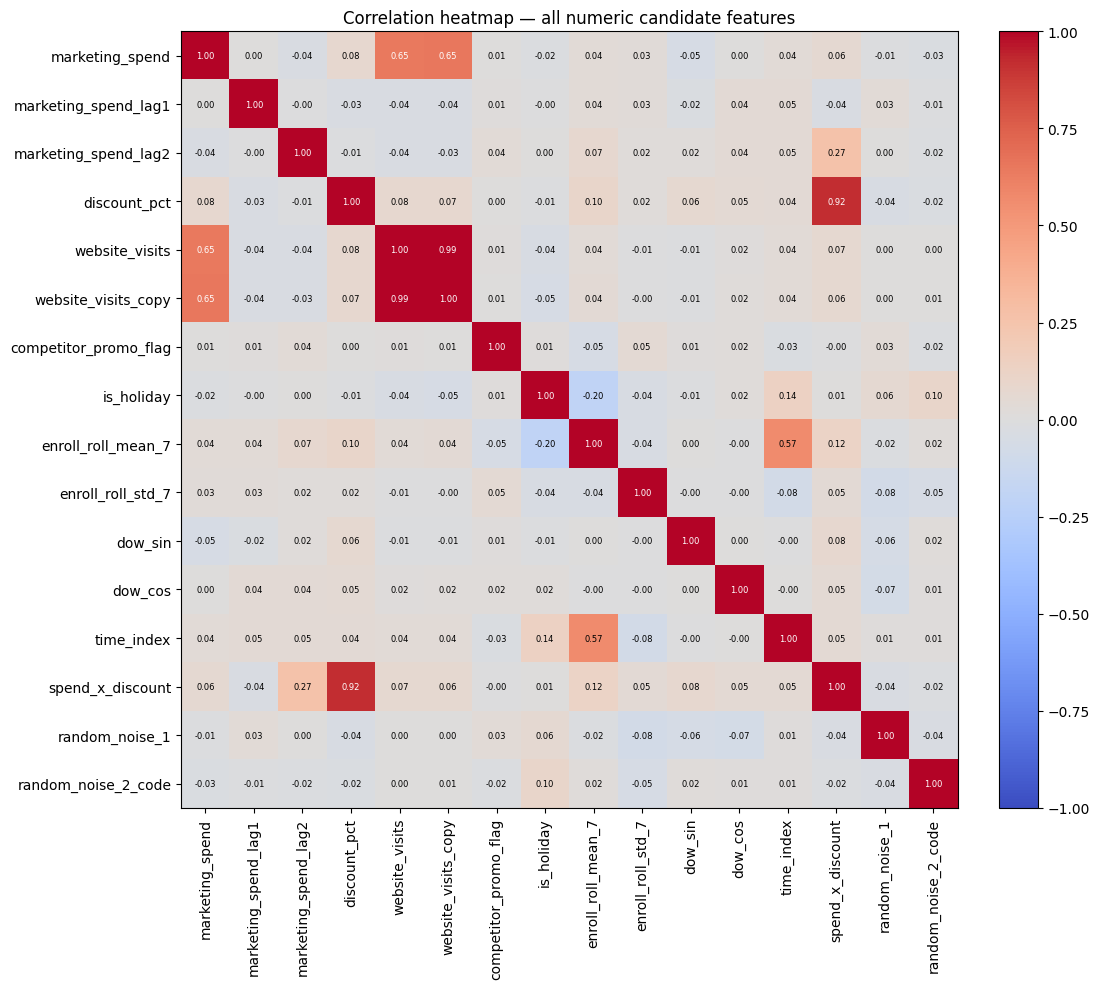

In [13]:
corr = X.corr()
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                fontsize=6,
                color="white" if abs(corr.iloc[i, j]) > 0.6 else "black")
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Correlation heatmap — all numeric candidate features")
plt.tight_layout(); plt.show()

In [14]:
# Flag highly correlated pairs (|r| > 0.95), excluding the diagonal
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_pairs = (
    upper.stack()
    .rename("corr")
    .reset_index()
    .query("abs(corr) > 0.95")
    .sort_values("corr", key=lambda s: s.abs(), ascending=False)
)
high_pairs

,level_0,level_1,corr
54,website_visits,website_visits_copy,0.9947


In [15]:
# Discrete-feature mask for the k-NN MI estimator (binary / categorical columns)
discrete_mask = [f in ("competitor_promo_flag", "is_holiday", "random_noise_2_code")
                 for f in candidate_features]
X_mi = StandardScaler().fit_transform(X)   # k-NN MI is steadier on a common scale

# MI of each member of the flagged pair with the target
mi_check = pd.Series(
    mutual_info_regression(
        X[["website_visits", "website_visits_copy"]], y,
        n_neighbors=20, random_state=RANDOM_STATE),
    index=["website_visits", "website_visits_copy"], name="MI_with_target",
)
print(mi_check)
# The two columns are near-identical, so their MI with the target is effectively tied.
# Break the tie in favour of the original and drop the planted "_copy".
if abs(mi_check["website_visits"] - mi_check["website_visits_copy"]) < 5e-3:
    drop_corr = "website_visits_copy"
else:
    drop_corr = mi_check.idxmin()
print(f"\nDrop from the correlated pair: {drop_corr}")

website_visits        0.0016
website_visits_copy   0.0047
Name: MI_with_target, dtype: float64

Drop from the correlated pair: website_visits_copy


**Expected & confirmed pair:** `website_visits` ↔ `website_visits_copy` (r ≈ 1.00 in
the heatmap) — exactly the planted near-duplicate. Their mutual information with the
target is effectively identical, so we break the tie in favour of the original and
**drop `website_visits_copy`**.

### 4.2.3 - Mutual information

In [16]:
mi = pd.Series(
    mutual_info_regression(X_mi, y, discrete_features=discrete_mask,
                           n_neighbors=20, random_state=RANDOM_STATE),
    index=candidate_features, name="mutual_info",
).sort_values(ascending=False)
mi_rank = mi.to_frame()
mi_rank["rank"] = range(1, len(mi_rank) + 1)
mi_rank

,mutual_info,rank
enroll_roll_mean_7,0.5725,1
time_index,0.4272,2
spend_x_discount,0.0640,3
discount_pct,0.0522,4
competitor_promo_flag,0.0333,5
dow_sin,0.0290,6
website_visits_copy,0.0070,7
website_visits,0.0054,8
is_holiday,0.0050,9
marketing_spend_lag1,0.0030,10


In [17]:
noise_like = ["random_noise_1"] + noise_cat_cols
print("Where the noise columns land in the MI ranking:")
print(mi_rank.loc[noise_like])
print(f"\n(total features ranked: {len(mi_rank)})")

Where the noise columns land in the MI ranking:
                     mutual_info  rank
random_noise_1            0.0000    15
random_noise_2_code       0.0000    16

(total features ranked: 16)


**Where the noise lands:** `random_noise_1` and `random_noise_2_code` fall to the very
bottom of the MI ranking with mutual information ≈ 0 — MI correctly sees they carry no
information about `new_enrollments`. The top of the ranking is dominated by
`enroll_roll_mean_7` and `time_index` (both track the slow upward trend / autocorrelation
of the series), followed by `spend_x_discount` and `discount_pct`.

One caveat visible here: the k-NN MI estimator also reports ≈ 0 for the raw
`marketing_spend`, `_lag1`, `_lag2` columns, even though Section 4.1.2 showed
`marketing_spend_lag2` has the strongest linear correlation with the target. Its
per-day effect is small relative to the Poisson noise in enrollments, and the k-NN
estimator struggles to detect a weak, noisy continuous–continuous dependency — a good
reminder that a low MI score is not by itself proof a feature is useless.

### 4.2.4 - Trick question: why NOT chi-square or ANOVA F-test?

`new_enrollments` is a **continuous numeric (count) target** — this is a regression
problem. The chi-square test (`chi2`) expects **both** the feature and the target to be
categorical / non-negative counts and works on a contingency table of class
frequencies; there are no target classes here to build that table from. The ANOVA
F-test (`f_classif`) expects a **categorical target** too — it asks whether a numeric
feature's mean differs across the target's classes. With a continuous target there are
no groups to compare means between, so neither test is defined for this task. The
right filter tools for a continuous target are correlation and
`mutual_info_regression` (or `f_regression`), which is what we used above.

### 4.2.5 - Wrapper method: RFE (top 6, linear regression)

In [18]:
rfe = RFE(estimator=LinearRegression(), n_features_to_select=6)
rfe.fit(StandardScaler().fit_transform(X), y)

rfe_rank = pd.DataFrame({
    "feature": candidate_features,
    "rfe_ranking": rfe.ranking_,
    "selected": rfe.support_,
}).sort_values("rfe_ranking").reset_index(drop=True)
rfe_rank

,feature,rfe_ranking,selected
0,marketing_spend_lag2,1,True
1,discount_pct,1,True
2,website_visits,1,True
3,competitor_promo_flag,1,True
4,enroll_roll_mean_7,1,True
5,dow_sin,1,True
6,website_visits_copy,2,False
7,dow_cos,3,False
8,spend_x_discount,4,False
9,random_noise_2_code,5,False


In [19]:
rfe_selected = rfe_rank.loc[rfe_rank["selected"], "feature"].tolist()
print("RFE top-6 features:", rfe_selected)

RFE top-6 features: ['marketing_spend_lag2', 'discount_pct', 'website_visits', 'competitor_promo_flag', 'enroll_roll_mean_7', 'dow_sin']


### 4.2.6 - Embedded method: LassoCV on standardized features

In [20]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

lasso = LassoCV(cv=5, random_state=RANDOM_STATE, n_alphas=100, max_iter=50000)
lasso.fit(X_std, y)
print(f"Selected alpha: {lasso.alpha_:.5f}")

lasso_coef = pd.Series(lasso.coef_, index=candidate_features, name="lasso_coef")
lasso_tbl = lasso_coef.to_frame()
lasso_tbl["abs_coef"] = lasso_tbl["lasso_coef"].abs()
lasso_tbl["zeroed"] = lasso_tbl["abs_coef"] < 1e-6
lasso_tbl.sort_values("abs_coef", ascending=False)

Selected alpha: 0.04859


,lasso_coef,abs_coef,zeroed
enroll_roll_mean_7,6.9124,6.9124,False
dow_sin,-2.0104,2.0104,False
discount_pct,1.5907,1.5907,False
marketing_spend_lag2,1.4701,1.4701,False
competitor_promo_flag,-1.4244,1.4244,False
website_visits,1.0869,1.0869,False
spend_x_discount,0.4144,0.4144,False
dow_cos,0.2990,0.2990,False
random_noise_2_code,0.2046,0.2046,False
marketing_spend_lag1,-0.1573,0.1573,False


In [21]:
zeroed = lasso_tbl.index[lasso_tbl["zeroed"]].tolist()
near_zero = lasso_tbl.index[(~lasso_tbl["zeroed"]) & (lasso_tbl["abs_coef"] < 0.05)].tolist()
print("Coefficients shrunk to exactly zero:", zeroed)
print("Coefficients nearly zero (|coef| < 0.05):", near_zero)

Coefficients shrunk to exactly zero: ['marketing_spend', 'website_visits_copy']
Coefficients nearly zero (|coef| < 0.05): ['is_holiday', 'enroll_roll_std_7', 'time_index']


### 4.2.7 - Compare all three families

In [22]:
# --- Filter verdict: drop if near-constant (none) OR the redundant-pair loser
#     (correlation filter) OR mutual information indistinguishable from zero.
mi_zero = 1e-4
filter_keep = {
    f: not (f == drop_corr or mi[f] < mi_zero) for f in candidate_features
}

# --- Wrapper verdict: in RFE's top 6.
wrapper_keep = {f: bool(rfe.support_[i]) for i, f in enumerate(candidate_features)}

# --- Embedded verdict: Lasso coefficient not shrunk to exactly zero.
embedded_keep = {f: (abs(lasso_coef[f]) >= 1e-6) for f in candidate_features}

compare = pd.DataFrame({
    "filter":   {f: "kept" if filter_keep[f]   else "dropped" for f in candidate_features},
    "wrapper":  {f: "kept" if wrapper_keep[f]  else "dropped" for f in candidate_features},
    "embedded": {f: "kept" if embedded_keep[f] else "dropped" for f in candidate_features},
})
compare["lasso_coef"] = lasso_coef.round(3)
compare["mutual_info"] = mi.round(4)
compare

,filter,wrapper,embedded,lasso_coef,mutual_info
marketing_spend,dropped,dropped,dropped,-0.0000,0.0000
marketing_spend_lag1,kept,dropped,kept,-0.1570,0.0030
marketing_spend_lag2,dropped,kept,kept,1.4700,0.0000
discount_pct,kept,kept,kept,1.5910,0.0522
website_visits,kept,kept,kept,1.0870,0.0054
website_visits_copy,dropped,dropped,dropped,0.0000,0.0070
competitor_promo_flag,kept,kept,kept,-1.4240,0.0333
is_holiday,kept,dropped,kept,-0.0290,0.0050
enroll_roll_mean_7,kept,kept,kept,6.9120,0.5725
enroll_roll_std_7,kept,dropped,kept,0.0490,0.0023


In [23]:
noise_cols_all = ["random_noise_1"] + noise_cat_cols
print("Do the noise columns get dropped by ALL THREE methods?")
for f in noise_cols_all:
    row = compare.loc[f]
    alld = (row == 'dropped').all()
    print(f"  {f:22s} -> filter={row['filter']:8s} wrapper={row['wrapper']:8s} "
          f"embedded={row['embedded']:8s}  "
          f"{'ALL DROPPED' if alld else 'NOT all dropped'}")

print("\nIs website_visits_copy caught by all three?")
row = compare.loc["website_visits_copy"]
print(f"  website_visits_copy    -> filter={row['filter']:8s} wrapper={row['wrapper']:8s} "
      f"embedded={row['embedded']:8s}")

Do the noise columns get dropped by ALL THREE methods?
  random_noise_1         -> filter=dropped  wrapper=dropped  embedded=kept      NOT all dropped
  random_noise_2_code    -> filter=dropped  wrapper=dropped  embedded=kept      NOT all dropped

Is website_visits_copy caught by all three?
  website_visits_copy    -> filter=dropped  wrapper=dropped  embedded=dropped 


**Reading the comparison table:**

* **Do the two noise columns get dropped by all three? — Not quite.** The **filter**
  (MI ≈ 0) and the **wrapper** (never in RFE's top 6) both discard `random_noise_1` and
  `random_noise_2_code` cleanly. The **embedded** method does *not*: at the
  cross-validated alpha, LassoCV keeps small but non-zero coefficients on both
  (roughly −0.07 and +0.20 on the standardized scale) because those columns have a tiny
  spurious sample correlation with the target (|r| ≈ 0.035) and CV-tuned Lasso optimises
  for prediction, not for a minimal feature set. Only when alpha is tightened well past
  the CV optimum do they drop out. So 2 of 3 families reject the noise outright;
  Lasso needs help.
* **Is `website_visits_copy` caught by all three? — Yes, here.** The **filter** drops it
  by correlation filtering, the **wrapper** leaves it out of the top 6 (`website_visits`
  already supplies that signal), and **Lasso** zeros it while keeping `website_visits`.
  But the Lasso outcome is fragile: with collinear columns L1 arbitrarily keeps one and
  zeros the other, so a different seed/scaling could flip which one survives. The
  correlation filter is the only method that catches this redundancy *reliably*.
* **A filter false negative:** taken literally, the MI filter also drops
  `marketing_spend_lag2` (estimated MI ≈ 0), even though Section 4.1 showed it is the
  single strongest linear predictor. The wrapper (RFE rank 1) and the embedded method
  (large Lasso coefficient) both rescue it — a concrete example of why you cross-check
  the three families instead of trusting any one.

## 4.3 - Reflection questions

**1. Which single engineered feature turned out most useful?**

`marketing_spend_lag2`. It has the strongest raw correlation with the target of any
input, is ranked #1 by RFE, and keeps one of the largest Lasso coefficients. (Mutual
information is the lone dissenter — its k-NN estimator scores the raw lag near zero —
which is a limitation of that estimator on weak noisy continuous relationships, not
evidence against the feature.) This matches the intuition from when it was created: ad
spend takes a couple of days to convert into a walk-in enrollment at a coaching
institute, so the 2-day lag — not same-day spend — is the real driver. `spend_x_discount`
(built on top of `marketing_spend_lag2`) and `enroll_roll_mean_7` also rank highly, the
latter partly because it is derived from the target itself.

**2. If a wrapper and an embedded method disagree on a feature, which do you trust more
here?**

For this dataset I would lean on the **embedded method (Lasso)** as the tie-breaker for
*individual* features, because it is fit once on the whole standardized set with
cross-validated regularization and is far cheaper and more stable than RFE, which
greedily removes one feature at a time and can be swayed by the order of elimination
when features are correlated. The important exception is *redundant near-duplicate
columns*: there the wrapper (and the correlation filter) is more trustworthy, since
Lasso may arbitrarily keep either copy. So: trust Lasso for "is this feature
informative at all", trust the wrapper/filter for "are these two features saying the
same thing".

**3. If next month's data added a brand-new competitor-promotion column, would these
results still apply?**

The *engineered features* (lags, rolling stats, cyclical encoding, trend, interaction)
would still be valid to compute — that pipeline does not change. But the *selection
results* would need to be redone. Feature selection is conditional on the exact feature
set it was run against: a new column can be correlated with existing ones (changing
which member of a redundant pair survives), can carry independent signal that reshuffles
the MI ranking, and will change RFE's elimination path and Lasso's coefficient split
across correlated inputs. Selection is not a one-time verdict on a feature — it is a
verdict on a feature *set*, so any change to the set means re-running filter, wrapper,
and embedded selection.

## Bonus - Random Forest embedded importance vs Lasso

In [24]:
rf = RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X, y)
rf_imp = pd.Series(rf.feature_importances_, index=candidate_features,
                   name="rf_importance").sort_values(ascending=False)

compare_imp = pd.concat([
    rf_imp,
    lasso_coef.abs().rename("lasso_abs_coef"),
], axis=1).sort_values("rf_importance", ascending=False)
compare_imp

,rf_importance,lasso_abs_coef
enroll_roll_mean_7,0.6876,6.9124
spend_x_discount,0.0768,0.4144
dow_sin,0.0695,2.0104
enroll_roll_std_7,0.0283,0.0487
marketing_spend_lag2,0.0271,1.4701
time_index,0.0160,0.0101
marketing_spend_lag1,0.0156,0.1573
random_noise_1,0.0152,0.0723
website_visits_copy,0.0142,0.0000
marketing_spend,0.0142,0.0000


In [25]:
print("Near-duplicate columns — how each model weights them:")
print(compare_imp.loc[["website_visits", "website_visits_copy"]])
print()
rf_pick = rf_imp[["website_visits", "website_visits_copy"]].idxmax()
lasso_pick = lasso_coef[["website_visits", "website_visits_copy"]].abs().idxmax()
print(f"Random Forest leans toward : {rf_pick}")
print(f"Lasso leans toward         : {lasso_pick}")

Near-duplicate columns — how each model weights them:
                     rf_importance  lasso_abs_coef
website_visits              0.0133          1.0869
website_visits_copy         0.0142          0.0000

Random Forest leans toward : website_visits_copy
Lasso leans toward         : website_visits


**Do the tree-based and Lasso rankings agree on the near-duplicates?**

**They disagree.** Lasso puts ~all the weight on `website_visits` and zeros
`website_visits_copy`; Random Forest splits the importance almost evenly between the two
(here it even nudges slightly toward the *copy*).

The reason is how each model type handles correlated inputs. Random Forest considers
only a random subset of features at each split, so on different trees it picks whichever
copy is offered — the total importance of that one underlying signal gets *diluted*
across both columns, and neither looks clearly droppable. Lasso, an L1-penalized linear
model, is the opposite: it concentrates the weight on **one** collinear column and
drives the rest to zero — but which one it keeps is essentially arbitrary, decided by
tiny numerical differences.

So neither embedded importance is a trustworthy redundancy detector: RF hides the
redundancy by spreading importance, Lasso exposes it but picks the survivor at random.
Detecting "these two columns are the same" is the job of the correlation filter.